# Machine Learning: The No-Nonsense (But Fun) Guide — Day 14
# XGBoost: The "Kaggle King" Algorithm 👑

**Series recap:** Day 12 → AdaBoost | Day 13 → Gradient Boosting | **Day 14 → XGBoost**

This notebook follows the same format as the previous days:
1. A **from-scratch implementation** of XGBoost (regularized objective, gain formula, approximate split finding, missing-value handling, shrinkage) so you understand *exactly* what's happening under the hood.
2. The **official `xgboost` library** implementation on the same real-world dataset, so you can compare.
3. Rich **visualizations** — loss curves, feature importance, ROC curves, hyperparameter effects, early stopping.
4. An **Interview Q&A** section at the end.

### Dataset
We use the **Breast Cancer Wisconsin (Diagnostic)** dataset — a real-world, tabular, binary classification problem (malignant vs. benign tumor), which is exactly the kind of structured/tabular data XGBoost dominates on (think: credit risk, fraud detection, medical risk scoring).


## 1. Story & Intuition

Yesterday we learned about **Gradient Boosting**, where trees are trained sequentially, and each new tree attempts to correct the errors (residuals) made by the previous trees.

**XGBoost** stands for **eXtreme Gradient Boosting**. It follows the same boosting principle but introduces numerous engineering and mathematical improvements that make it significantly faster, more accurate, and less prone to overfitting.

> Gradient Boosting walks. XGBoost runs — with rocket boots. 🚀

### Why is XGBoost so popular?
- Winner of numerous Kaggle competitions
- Handles millions of training samples efficiently
- Built-in **regularization** reduces overfitting
- Supports **parallel processing**
- **Automatically handles missing values**
- Supports **GPU acceleration**
- Includes **early stopping** for optimal training

## 2. What Makes XGBoost "Extreme"?

| Regular Gradient Boosting | XGBoost |
|---|---|
| Sequential training only | Parallel + Sequential optimization |
| No built-in regularization | L1 and L2 regularization |
| Simple split searching | Weighted quantile sketch algorithm |
| Missing values require preprocessing | Automatically handles missing values |
| CPU only | CPU and GPU support |
| No early stopping | Built-in early stopping |
| Slower training | Much faster training |

**Key Idea:** XGBoost doesn't simply improve Gradient Boosting — it optimizes almost every part of the learning process.


## 3. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay)

import xgboost as xgb
from xgboost import XGBClassifier

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("xgboost version:", xgb.__version__)


xgboost version: 3.3.0


## 4. Real-World Dataset: Breast Cancer Wisconsin (Diagnostic)

**Task:** Predict whether a tumor is **malignant (0)** or **benign (1)** from 30 numeric features computed from digitized images of a breast mass (radius, texture, perimeter, area, smoothness, etc.).

This is a genuine, widely-used real-world medical dataset (569 patients, 30 features) — a great stand-in for the kind of *tabular, structured* risk-prediction problem (credit risk, disease risk, fraud) that the guide says XGBoost excels at.


In [2]:
data = load_breast_cancer()
X_full = data.data
y_full = data.target
feature_names = data.data if False else data.feature_names

df = pd.DataFrame(X_full, columns=feature_names)
df["target"] = y_full
df["diagnosis"] = df["target"].map({0: "Malignant", 1: "Benign"})

print("Shape:", df.shape)
df.head()


Shape: (569, 32)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


In [3]:
print(df["diagnosis"].value_counts())
print("\nClass balance (%):")
print((df["diagnosis"].value_counts(normalize=True) * 100).round(2))


diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64

Class balance (%):
diagnosis
Benign       62.74
Malignant    37.26
Name: proportion, dtype: float64


/tmp/ipykernel_621/2845231676.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="diagnosis", palette=["#e74c3c", "#2ecc71"], ax=axes[0])
/tmp/ipykernel_621/2845231676.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette="viridis", ax=axes[1])


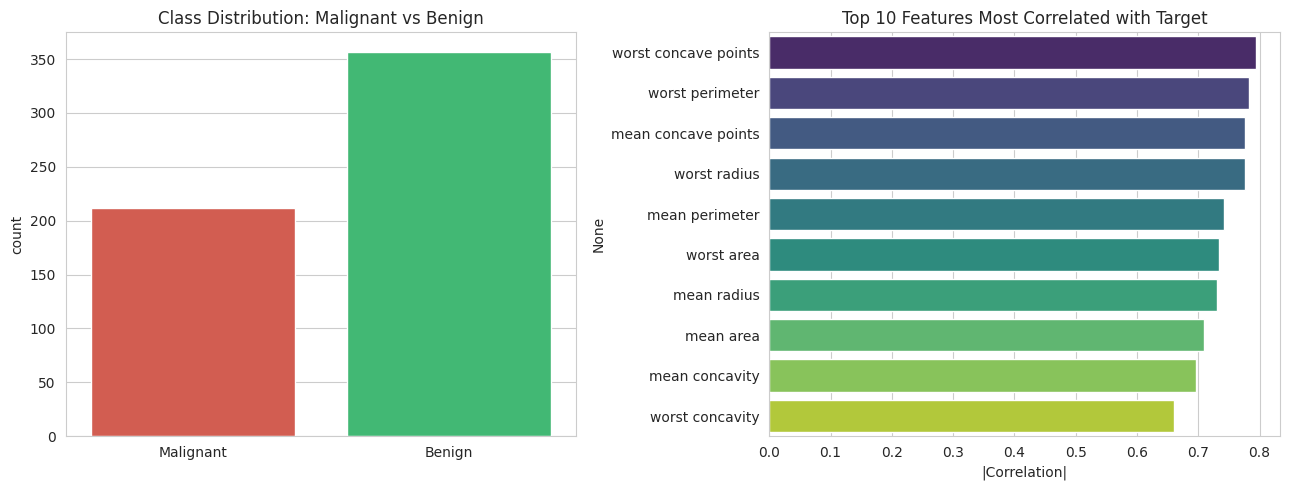

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=df, x="diagnosis", palette=["#e74c3c", "#2ecc71"], ax=axes[0])
axes[0].set_title("Class Distribution: Malignant vs Benign")
axes[0].set_xlabel("")

top_corr = df.corr(numeric_only=True)["target"].drop("target").abs().sort_values(ascending=False).head(10)
sns.barplot(x=top_corr.values, y=top_corr.index, palette="viridis", ax=axes[1])
axes[1].set_title("Top 10 Features Most Correlated with Target")
axes[1].set_xlabel("|Correlation|")

plt.tight_layout()
plt.show()


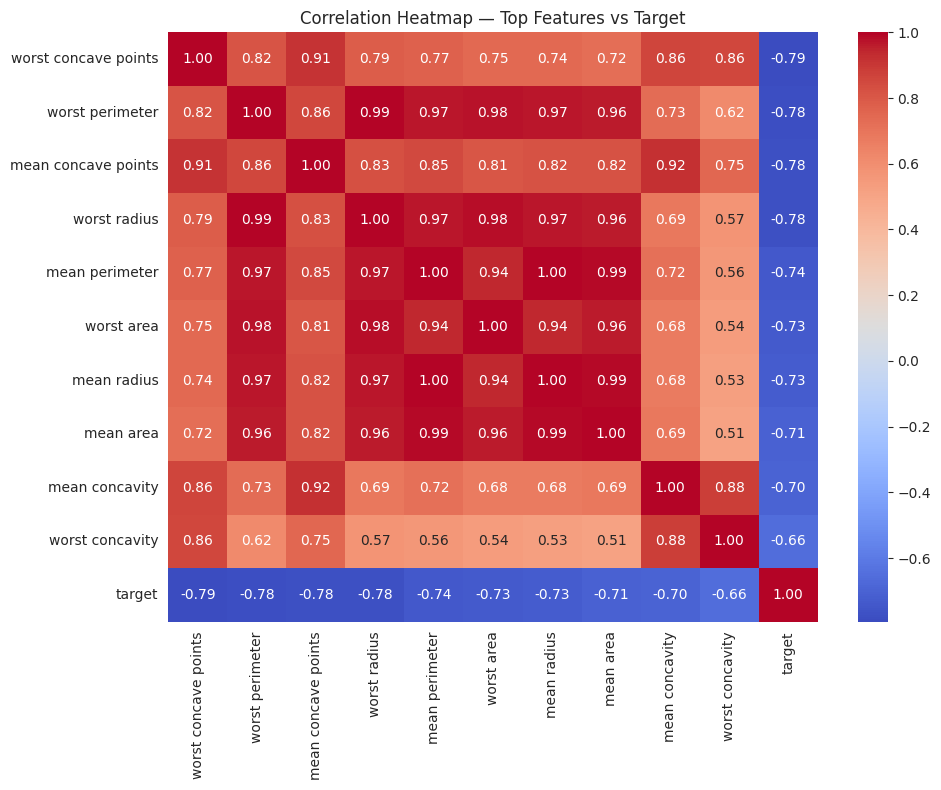

In [5]:
plt.figure(figsize=(10, 8))
top_features = top_corr.head(10).index.tolist() + ["target"]
corr_matrix = df[top_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap — Top Features vs Target")
plt.tight_layout()
plt.show()


## 5. Train/Test Split & Baseline Models

Before building XGBoost, let's set a baseline with **Random Forest** (bagging) and **Gradient Boosting** (plain sequential boosting, no regularization) — this mirrors Section 5 of the guide (*XGBoost vs Gradient Boosting vs Random Forest*).


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=RANDOM_STATE, stratify=y_full
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

results = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, proba_func=None):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0
    preds = model.predict(X_te)
    proba = proba_func(X_te) if proba_func else model.predict_proba(X_te)[:, 1]
    results[name] = {
        "Accuracy": accuracy_score(y_te, preds),
        "Precision": precision_score(y_te, preds),
        "Recall": recall_score(y_te, preds),
        "F1": f1_score(y_te, preds),
        "AUC": roc_auc_score(y_te, proba),
        "Train Time (s)": train_time,
    }
    return model, preds, proba

rf_model, rf_preds, rf_proba = evaluate_model(
    "Random Forest", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    X_train, y_train, X_test, y_test
)

gb_model, gb_preds, gb_proba = evaluate_model(
    "Gradient Boosting (sklearn)", GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    X_train, y_train, X_test, y_test
)

pd.DataFrame(results).T.round(4)


Train shape: (455, 30) Test shape: (114, 30)


,Accuracy,Precision,Recall,F1,AUC,Train Time (s)
Random Forest,0.9561,0.9589,0.9722,0.9655,0.9931,0.3145
Gradient Boosting (sklearn),0.9561,0.9467,0.9861,0.9660,0.9907,0.3363


## 6. How XGBoost Works

### 6.1 Regularized Objective Function

Unlike traditional Gradient Boosting, XGBoost optimizes both **prediction accuracy** and **model simplicity**.

**Objective = Training Loss + Regularization**

$$\text{Obj} = \sum_i l(y_i, \hat{y}_i) + \sum_k \Omega(f_k)$$

where the regularization term for a tree with $T$ leaves and leaf weights $w$ is:

$$\Omega(f) = \gamma T + \tfrac{1}{2}\lambda \sum_j w_j^2$$

- $T$ = number of leaf nodes
- $w$ = leaf weights
- $\gamma$ (gamma) = penalty for creating additional leaves
- $\lambda$ (lambda) = L2 regularization strength

Using a **second-order Taylor expansion** of the loss around the current prediction, each training example contributes a **gradient** $g_i$ and a **Hessian** $h_i$. For a candidate split into left (L) and right (R) child sets, the **gain** of the split is:

$$\text{Gain} = \tfrac{1}{2}\left[\frac{G_L^2}{H_L+\lambda} + \frac{G_R^2}{H_R+\lambda} - \frac{(G_L+G_R)^2}{H_L+H_R+\lambda}\right] - \gamma$$

where $G = \sum g_i$ and $H = \sum h_i$ over the examples in each set. If **Gain ≤ 0**, XGBoost prefers **not to split** — this is exactly how $\gamma$ prunes the tree.

The optimal leaf weight (once a leaf is decided) is:

$$w^{*} = -\frac{G}{H+\lambda}$$

### 6.2 Approximate Greedy Split Finding
Instead of scanning every possible split value (expensive), XGBoost:
1. Sorts feature values
2. Uses **percentiles** as candidate split points (weighted quantile sketch)
3. Evaluates only those candidates

### 6.3 Column Blocks for Parallel Processing
Features are stored in **sorted column blocks** so multiple CPU cores can search for the best split on different features simultaneously.

### 6.4 Automatic Handling of Missing Values
For every candidate split, XGBoost tries sending **all missing values to the left child AND to the right child**, computes the gain for both options, and **learns the better default direction** — the one that minimizes the loss. No manual imputation required.

We implement **all four ideas above** from scratch below (binary logistic classification case).


## 7. From-Scratch XGBoost Implementation

We build:
- `XGTree`: a single regression tree grown using the **gain formula** above, with **approximate (percentile-based) split finding**, `min_child_weight` pruning, and **learned missing-value default direction**.
- `XGBoostScratch`: an ensemble of `XGTree`s trained via **gradient boosting on the logistic loss** (binary classification), using `learning_rate` (shrinkage), `reg_lambda` ($\lambda$), and `gamma`.

This is a simplified, educational version of the real algorithm (real XGBoost also does weighted quantile sketches with exact algorithms for small data, GPU histograms, DMatrix compression, etc.) — but the **core math is identical**.


In [7]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


class XGNode:
    __slots__ = ["feature", "threshold", "left", "right", "value", "is_leaf", "missing_go_left"]

    def __init__(self):
        self.feature = None
        self.threshold = None
        self.left = None
        self.right = None
        self.value = 0.0
        self.is_leaf = False
        self.missing_go_left = True


class XGTree:
    '''A single CART regression tree grown with XGBoost's regularized gain formula.'''

    def __init__(self, max_depth=3, lam=1.0, gamma=0.0, min_child_weight=1.0, n_bins=32):
        self.max_depth = max_depth
        self.lam = lam
        self.gamma = gamma
        self.min_child_weight = min_child_weight
        self.n_bins = n_bins  # approximate split finding: number of percentile candidates
        self.root = None

    def _leaf_value(self, g, h):
        return -np.sum(g) / (np.sum(h) + self.lam)

    def _gain(self, gl, hl, gr, hr):
        def term(g, h):
            return (g ** 2) / (h + self.lam)
        return 0.5 * (term(gl, hl) + term(gr, hr) - term(gl + gr, hl + hr)) - self.gamma

    def _best_split(self, X, g, h, idx):
        '''Approximate greedy split search using percentile candidates (Section 3.2),
        also evaluating both missing-value default directions (Section 3.4).'''
        best = {"gain": 0.0, "feature": None, "threshold": None, "missing_go_left": True}

        for f in range(X.shape[1]):
            col = X[idx, f]
            finite_mask = ~np.isnan(col)
            if finite_mask.sum() == 0:
                continue

            candidates = np.unique(np.percentile(col[finite_mask], np.linspace(0, 100, self.n_bins)))

            for thr in candidates:
                left_mask = (col <= thr) & finite_mask
                right_mask = (col > thr) & finite_mask
                missing_mask = ~finite_mask

                gl_base, hl_base = np.sum(g[idx][left_mask]), np.sum(h[idx][left_mask])
                gr_base, hr_base = np.sum(g[idx][right_mask]), np.sum(h[idx][right_mask])
                gm, hm = np.sum(g[idx][missing_mask]), np.sum(h[idx][missing_mask])

                # Option A: missing values go LEFT
                gl, hl = gl_base + gm, hl_base + hm
                gr, hr = gr_base, hr_base
                if hl >= self.min_child_weight and hr >= self.min_child_weight:
                    gain = self._gain(gl, hl, gr, hr)
                    if gain > best["gain"]:
                        best.update(gain=gain, feature=f, threshold=thr, missing_go_left=True)

                # Option B: missing values go RIGHT
                gl2, hl2 = gl_base, hl_base
                gr2, hr2 = gr_base + gm, hr_base + hm
                if hl2 >= self.min_child_weight and hr2 >= self.min_child_weight:
                    gain2 = self._gain(gl2, hl2, gr2, hr2)
                    if gain2 > best["gain"]:
                        best.update(gain=gain2, feature=f, threshold=thr, missing_go_left=False)

        return best

    def _build(self, X, g, h, idx, depth):
        node = XGNode()
        if depth >= self.max_depth or len(idx) < 2:
            node.is_leaf = True
            node.value = self._leaf_value(g[idx], h[idx])
            return node

        best = self._best_split(X, g, h, idx)
        if best["feature"] is None:  # no split improves the gain -> gamma pruned everything
            node.is_leaf = True
            node.value = self._leaf_value(g[idx], h[idx])
            return node

        f, thr = best["feature"], best["threshold"]
        col = X[idx, f]
        finite_mask = ~np.isnan(col)
        missing_go_left = best["missing_go_left"]

        left_idx_mask = (col <= thr) & finite_mask
        right_idx_mask = (col > thr) & finite_mask
        missing_idx_mask = ~finite_mask

        if missing_go_left:
            left_idx_mask = left_idx_mask | missing_idx_mask
        else:
            right_idx_mask = right_idx_mask | missing_idx_mask

        node.feature, node.threshold, node.missing_go_left = f, thr, missing_go_left
        node.left = self._build(X, g, h, idx[left_idx_mask], depth + 1)
        node.right = self._build(X, g, h, idx[right_idx_mask], depth + 1)
        return node

    def fit(self, X, g, h):
        idx = np.arange(X.shape[0])
        self.root = self._build(X, g, h, idx, 0)
        return self

    def _predict_row(self, row, node):
        while not node.is_leaf:
            val = row[node.feature]
            if np.isnan(val):
                node = node.left if node.missing_go_left else node.right
            elif val <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node.value

    def predict(self, X):
        return np.array([self._predict_row(row, self.root) for row in X])


class XGBoostScratch:
    '''Gradient boosting on the logistic loss using XGTree as the weak learner.'''

    def __init__(self, n_estimators=60, learning_rate=0.3, max_depth=3,
                 lam=1.0, gamma=0.0, min_child_weight=1.0):
        self.n_estimators = n_estimators
        self.lr = learning_rate
        self.max_depth = max_depth
        self.lam = lam
        self.gamma = gamma
        self.min_child_weight = min_child_weight
        self.trees = []
        self.base_score = 0.0
        self.train_logloss = []

    def fit(self, X, y):
        p = np.clip(np.mean(y), 1e-6, 1 - 1e-6)
        self.base_score = np.log(p / (1 - p))  # log-odds base score
        raw = np.full(shape=y.shape, fill_value=self.base_score, dtype=float)

        for _ in range(self.n_estimators):
            pred = sigmoid(raw)
            g = pred - y            # gradient of logistic loss
            h = pred * (1 - pred)   # hessian of logistic loss

            tree = XGTree(max_depth=self.max_depth, lam=self.lam, gamma=self.gamma,
                           min_child_weight=self.min_child_weight)
            tree.fit(X, g, h)

            raw += self.lr * tree.predict(X)   # shrinkage / learning_rate (eta)
            self.trees.append(tree)

            eps = 1e-12
            pred_now = sigmoid(raw)
            ll = -np.mean(y * np.log(pred_now + eps) + (1 - y) * np.log(1 - pred_now + eps))
            self.train_logloss.append(ll)
        return self

    def predict_proba(self, X):
        raw = np.full(shape=(X.shape[0],), fill_value=self.base_score, dtype=float)
        for tree in self.trees:
            raw += self.lr * tree.predict(X)
        p = sigmoid(raw)
        return np.vstack([1 - p, p]).T

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X)[:, 1] >= threshold).astype(int)

print("From-scratch XGBoost classes defined successfully.")


From-scratch XGBoost classes defined successfully.


### 7.1 Train the from-scratch model

In [8]:
scratch_model = XGBoostScratch(
    n_estimators=60, learning_rate=0.3, max_depth=3,
    lam=1.0, gamma=0.0, min_child_weight=1.0
)

t0 = time.time()
scratch_model.fit(X_train, y_train)
scratch_train_time = time.time() - t0

scratch_preds = scratch_model.predict(X_test)
scratch_proba = scratch_model.predict_proba(X_test)[:, 1]

results["XGBoost (From Scratch)"] = {
    "Accuracy": accuracy_score(y_test, scratch_preds),
    "Precision": precision_score(y_test, scratch_preds),
    "Recall": recall_score(y_test, scratch_preds),
    "F1": f1_score(y_test, scratch_preds),
    "AUC": roc_auc_score(y_test, scratch_proba),
    "Train Time (s)": scratch_train_time,
}

pd.DataFrame(results).T.round(4)


,Accuracy,Precision,Recall,F1,AUC,Train Time (s)
Random Forest,0.9561,0.9589,0.9722,0.9655,0.9931,0.3145
Gradient Boosting (sklearn),0.9561,0.9467,0.9861,0.9660,0.9907,0.3363
XGBoost (From Scratch),0.9649,0.9595,0.9861,0.9726,0.9931,8.1597


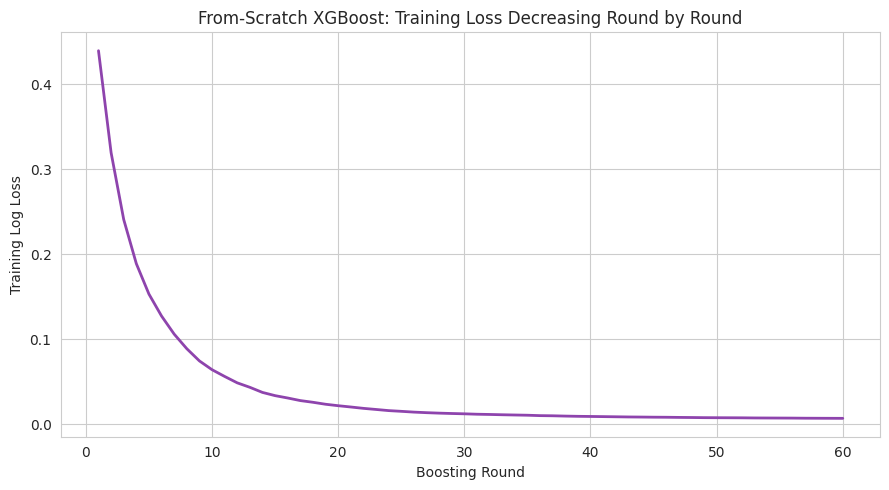

In [9]:
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(scratch_model.train_logloss) + 1), scratch_model.train_logloss,
         color="#8e44ad", linewidth=2)
plt.xlabel("Boosting Round")
plt.ylabel("Training Log Loss")
plt.title("From-Scratch XGBoost: Training Loss Decreasing Round by Round")
plt.tight_layout()
plt.show()


## 8. Official `xgboost` Library Implementation

Now let's train the real, production-grade XGBoost library with (roughly) matching hyperparameters, and compare.


In [10]:
xgb_model = XGBClassifier(
    n_estimators=60,
    learning_rate=0.3,
    max_depth=3,
    reg_lambda=1.0,
    gamma=0.0,
    min_child_weight=1.0,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

xgb_model, xgb_preds, xgb_proba = evaluate_model(
    "XGBoost (Library)", xgb_model, X_train, y_train, X_test, y_test
)

pd.DataFrame(results).T.round(4).sort_values("AUC", ascending=False)


,Accuracy,Precision,Recall,F1,AUC,Train Time (s)
Random Forest,0.9561,0.9589,0.9722,0.9655,0.9931,0.3145
XGBoost (From Scratch),0.9649,0.9595,0.9861,0.9726,0.9931,8.1597
Gradient Boosting (sklearn),0.9561,0.9467,0.9861,0.9660,0.9907,0.3363
XGBoost (Library),0.9474,0.9459,0.9722,0.9589,0.9897,0.0279


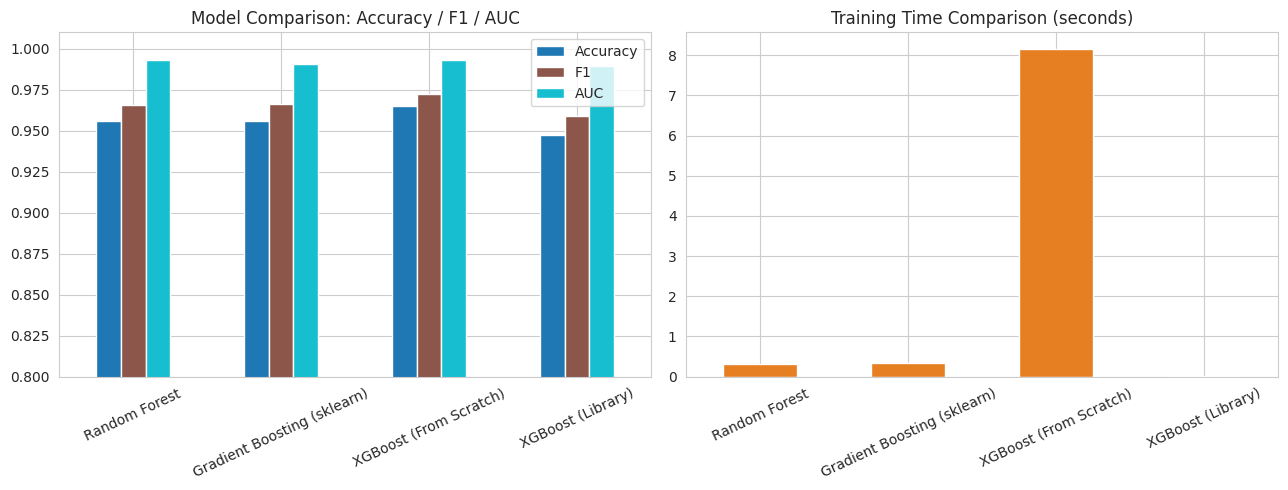

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metrics_df = pd.DataFrame(results).T[["Accuracy", "F1", "AUC"]]
metrics_df.plot(kind="bar", ax=axes[0], colormap="tab10")
axes[0].set_title("Model Comparison: Accuracy / F1 / AUC")
axes[0].set_ylim(0.8, 1.01)
axes[0].tick_params(axis='x', rotation=25)

time_df = pd.DataFrame(results).T[["Train Time (s)"]]
time_df.plot(kind="bar", ax=axes[1], color="#e67e22", legend=False)
axes[1].set_title("Training Time Comparison (seconds)")
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()


## 9. Confusion Matrix & ROC Curve (Library XGBoost)

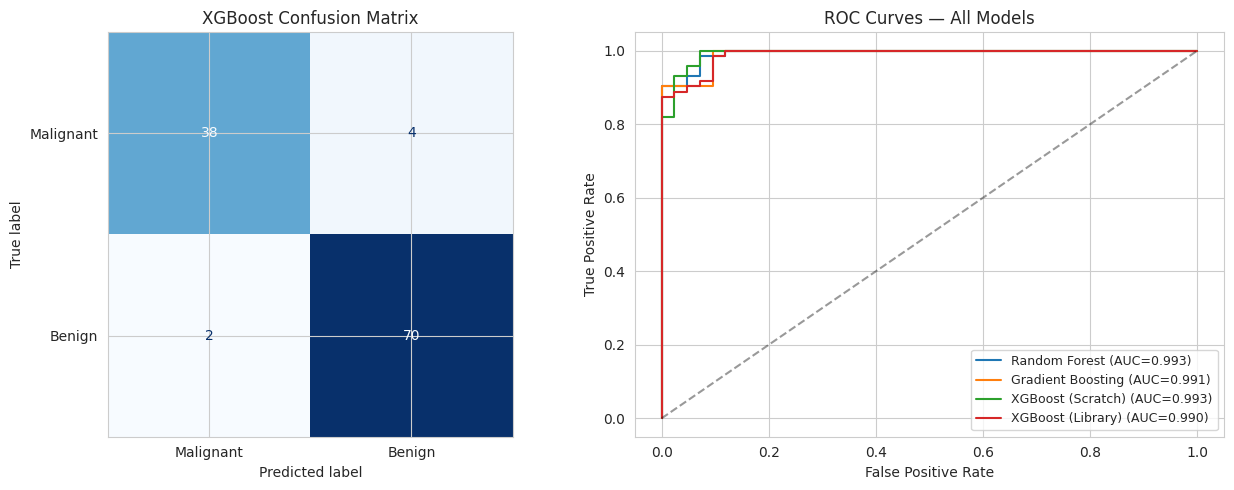

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, xgb_preds)
ConfusionMatrixDisplay(cm, display_labels=["Malignant", "Benign"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("XGBoost Confusion Matrix")

for name, proba in [("Random Forest", rf_proba), ("Gradient Boosting", gb_proba),
                     ("XGBoost (Scratch)", scratch_proba), ("XGBoost (Library)", xgb_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")

axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curves — All Models")
axes[1].legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()


## 10. Feature Importance (Library XGBoost)

/tmp/ipykernel_621/1962760310.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="mako")


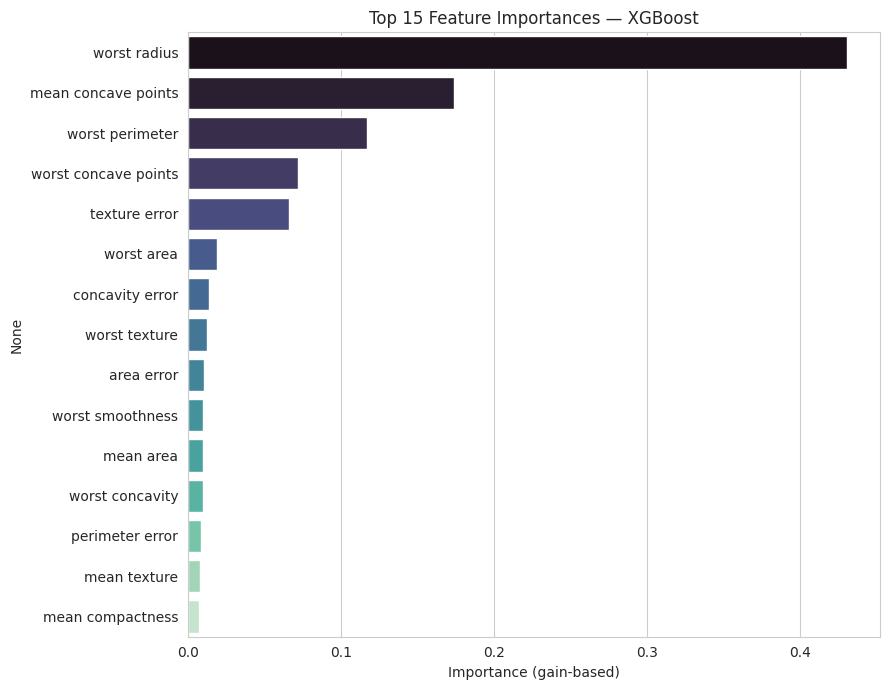

In [13]:
importances = pd.Series(xgb_model.feature_importances_, index=data.feature_names)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(x=importances.values, y=importances.index, palette="mako")
plt.title("Top 15 Feature Importances — XGBoost")
plt.xlabel("Importance (gain-based)")
plt.tight_layout()
plt.show()


## 11. Important Hyperparameters & Their Effects

| Parameter | Purpose | Typical Default | Common Range |
|---|---|---|---|
| `max_depth` | Maximum tree depth | 3–6 | 3–10 |
| `learning_rate` (eta) | Controls contribution of each tree | 0.1 | 0.01–0.3 |
| `n_estimators` | Number of boosting rounds | 100 | 100–1000 |
| `subsample` | Fraction of training rows used | 0.8 | 0.5–1.0 |
| `colsample_bytree` | Fraction of features used per tree | 0.8 | 0.5–1.0 |
| `reg_alpha` | L1 regularization | 0 | 0–1 |
| `reg_lambda` | L2 regularization | 1 | 0–10 |
| `min_child_weight` | Minimum weight in a leaf | 1 | 1–10 |
| `gamma` | Minimum loss reduction before split | 0 | 0–5 |
| `scale_pos_weight` | Balances imbalanced datasets | 1 | Depends on class ratio |

Let's visualize how **`learning_rate`** and **`max_depth`** actually affect test accuracy on our dataset.


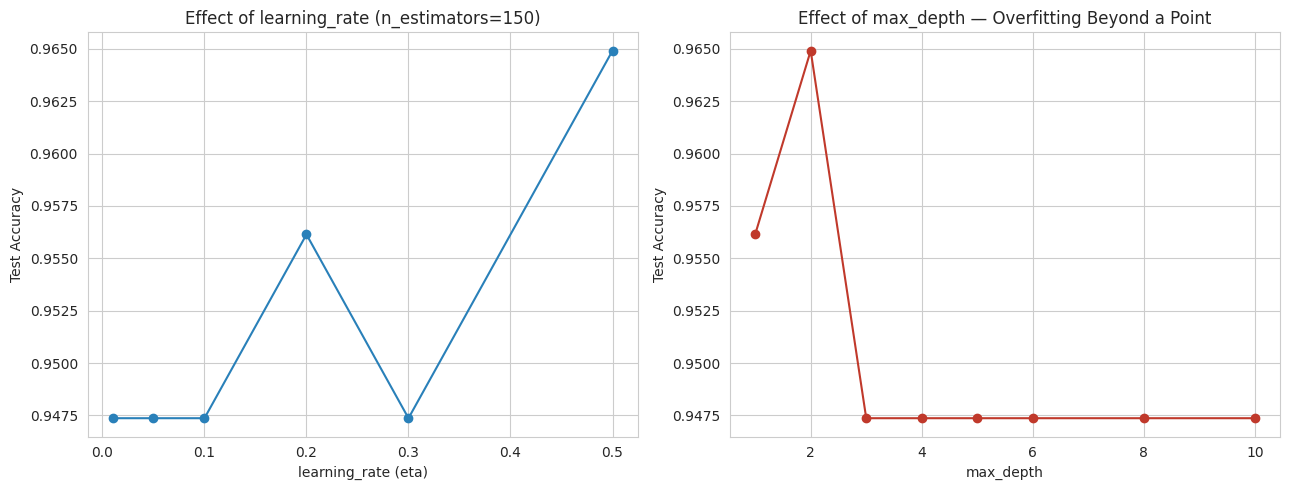

In [14]:
learning_rates = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
lr_scores = []
for lr in learning_rates:
    m = XGBClassifier(n_estimators=150, learning_rate=lr, max_depth=3,
                       eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(X_train, y_train)
    lr_scores.append(accuracy_score(y_test, m.predict(X_test)))

depths = [1, 2, 3, 4, 5, 6, 8, 10]
depth_scores = []
for d in depths:
    m = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=d,
                       eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(X_train, y_train)
    depth_scores.append(accuracy_score(y_test, m.predict(X_test)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(learning_rates, lr_scores, marker="o", color="#2980b9")
axes[0].set_xlabel("learning_rate (eta)")
axes[0].set_ylabel("Test Accuracy")
axes[0].set_title("Effect of learning_rate (n_estimators=150)")

axes[1].plot(depths, depth_scores, marker="o", color="#c0392b")
axes[1].set_xlabel("max_depth")
axes[1].set_ylabel("Test Accuracy")
axes[1].set_title("Effect of max_depth — Overfitting Beyond a Point")

plt.tight_layout()
plt.show()


## 12. Automatic Handling of Missing Values (Section 3.4 in Action)

Many algorithms (like sklearn's `GradientBoostingClassifier`) **cannot handle `NaN`s at all** and will raise an error. XGBoost **learns the optimal direction for missing values during training** — no imputation needed.

We'll corrupt 15% of the values in the top features with `NaN` and compare.


In [15]:
X_train_missing = X_train.copy()
X_test_missing = X_test.copy()

rng = np.random.RandomState(RANDOM_STATE)
missing_mask_train = rng.rand(*X_train_missing.shape) < 0.15
missing_mask_test = rng.rand(*X_test_missing.shape) < 0.15
X_train_missing[missing_mask_train] = np.nan
X_test_missing[missing_mask_test] = np.nan

print(f"Missing values introduced: {np.isnan(X_train_missing).sum()} in train, "
      f"{np.isnan(X_test_missing).sum()} in test")

# 1) sklearn's GradientBoostingClassifier CANNOT handle NaNs directly
try:
    gb_missing = GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)
    gb_missing.fit(X_train_missing, y_train)
except ValueError as e:
    print("\nsklearn GradientBoostingClassifier failed on missing data, as expected:")
    print(">>", str(e)[:150], "...")

# 2) XGBoost handles NaNs natively - no imputation needed!
xgb_missing = XGBClassifier(n_estimators=60, learning_rate=0.3, max_depth=3,
                             eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1)
xgb_missing.fit(X_train_missing, y_train)
xgb_missing_preds = xgb_missing.predict(X_test_missing)
xgb_missing_acc = accuracy_score(y_test, xgb_missing_preds)

# 3) Our from-scratch model also handles NaNs (we implemented the default-direction logic!)
scratch_missing = XGBoostScratch(n_estimators=60, learning_rate=0.3, max_depth=3)
scratch_missing.fit(X_train_missing, y_train)
scratch_missing_acc = accuracy_score(y_test, scratch_missing.predict(X_test_missing))

print(f"\nXGBoost (Library) accuracy WITH missing values (no imputation): {xgb_missing_acc:.4f}")
print(f"XGBoost (Scratch)  accuracy WITH missing values (no imputation): {scratch_missing_acc:.4f}")
print(f"Original XGBoost (Library) accuracy on clean data:               {results['XGBoost (Library)']['Accuracy']:.4f}")


Missing values introduced: 2072 in train, 516 in test

sklearn GradientBoostingClassifier failed on missing data, as expected:
>> Input X contains NaN.
GradientBoostingClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to co ...



XGBoost (Library) accuracy WITH missing values (no imputation): 0.9561
XGBoost (Scratch)  accuracy WITH missing values (no imputation): 0.9649
Original XGBoost (Library) accuracy on clean data:               0.9474


## 13. Built-In Early Stopping

XGBoost can monitor performance on a validation set during training and **stop early** once it stops improving, preventing overfitting and saving compute.


Best iteration: 104 (out of max 500 requested)


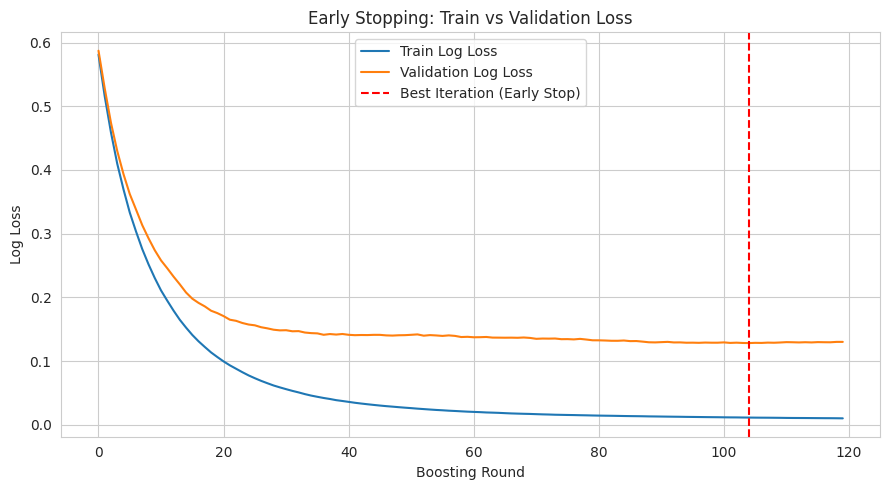

In [16]:
X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
)

es_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=3,
    eval_metric="logloss",
    early_stopping_rounds=15,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

es_model.fit(X_tr2, y_tr2, eval_set=[(X_tr2, y_tr2), (X_val, y_val)], verbose=False)

results_dict = es_model.evals_result()
train_ll = results_dict["validation_0"]["logloss"]
val_ll = results_dict["validation_1"]["logloss"]

print(f"Best iteration: {es_model.best_iteration} (out of max 500 requested)")

plt.figure(figsize=(9, 5))
plt.plot(train_ll, label="Train Log Loss")
plt.plot(val_ll, label="Validation Log Loss")
plt.axvline(es_model.best_iteration, color="red", linestyle="--", label="Best Iteration (Early Stop)")
plt.xlabel("Boosting Round")
plt.ylabel("Log Loss")
plt.title("Early Stopping: Train vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()


## 14. Final Model Comparison

In [17]:
final_comparison = pd.DataFrame(results).T.round(4)
final_comparison = final_comparison.sort_values("AUC", ascending=False)
final_comparison


,Accuracy,Precision,Recall,F1,AUC,Train Time (s)
Random Forest,0.9561,0.9589,0.9722,0.9655,0.9931,0.3145
XGBoost (From Scratch),0.9649,0.9595,0.9861,0.9726,0.9931,8.1597
Gradient Boosting (sklearn),0.9561,0.9467,0.9861,0.9660,0.9907,0.3363
XGBoost (Library),0.9474,0.9459,0.9722,0.9589,0.9897,0.0279


### XGBoost vs Gradient Boosting vs Random Forest

| Feature | Random Forest | Gradient Boosting | XGBoost |
|---|---|---|---|
| Learning Strategy | Bagging | Boosting | Optimized Boosting |
| Training Speed | Fast | Moderate | Very Fast |
| Regularization | No | Limited | L1 + L2 |
| Missing Value Support | No | No | Yes |
| Parallel Processing | Yes | Limited | Yes |
| Early Stopping | No | No | Yes |
| GPU Support | No | No | Yes |
| Best For | General ensemble tasks | Learning boosting | High-performance machine learning |


## 15. When Should You Use XGBoost?

**Recommended for:**
- Tabular datasets
- Structured business data
- Credit risk prediction
- Fraud detection
- Recommendation systems
- Large datasets
- Machine learning competitions
- Feature interaction problems

**Avoid using XGBoost for:**
- Image classification (CNNs perform better)
- Natural language processing (Transformers are preferred)
- Extremely simple baseline models
- Applications requiring maximum interpretability

## 16. Common Problems and Their Solutions

| Problem | Symptom | Solution |
|---|---|---|
| Overfitting | High training accuracy, low testing accuracy | Reduce tree depth, increase regularization, decrease learning rate |
| Underfitting | Low accuracy on both training and testing | Increase number of trees or increase tree depth |
| Slow Training | Model takes too long | Use GPU acceleration or reduce boosting rounds |
| Imbalanced Classes | Predicts majority class only | Adjust class weights using `scale_pos_weight` |
| Memory Issues | Dataset too large | Use optimized data structures such as `DMatrix` |

## 17. Real-World Applications

| Application | Why XGBoost Works Well |
|---|---|
| Kaggle Competitions | High predictive accuracy |
| Credit Scoring | Handles missing values and feature interactions |
| Fraud Detection | Detects complex patterns efficiently |
| Recommendation Systems | Learns rich feature relationships |
| Click-Through Rate Prediction | Handles sparse, high-dimensional data |
| Insurance Pricing | Works well with SHAP explanations |


## 18. Interview Questions & Answers

**1. What makes XGBoost faster than traditional Gradient Boosting?**
XGBoost uses approximate (percentile/quantile-based) split finding instead of exhaustive search, stores data in pre-sorted column blocks to parallelize split search across CPU cores, supports GPU acceleration, uses cache-aware access patterns, and can build histograms instead of scanning raw data — all of which reduce the per-tree training cost compared to plain sequential Gradient Boosting.

**2. How does XGBoost automatically handle missing values?**
For every candidate split, XGBoost evaluates sending all missing values to the left child and, separately, to the right child, computes the resulting gain for each option using the gradient/Hessian statistics, and keeps whichever default direction produces higher gain. That learned "default direction" is stored in the tree and used at prediction time, so no manual imputation is required.

**3. Explain the difference between `reg_alpha` and `reg_lambda`.**
Both are regularization terms added to the objective to control model complexity. `reg_alpha` is the L1 penalty on leaf weights, which pushes some leaf weights toward exactly zero (a sparsifying effect). `reg_lambda` is the L2 penalty (the $\lambda$ in $\Omega(f)=\gamma T + \tfrac12\lambda\sum w_j^2$), which shrinks leaf weights smoothly toward zero without necessarily zeroing them out, and also stabilizes the denominator in the gain/leaf-weight formulas.

**4. What is early stopping and why is it useful?**
Early stopping monitors a chosen metric (e.g., log loss or AUC) on a held-out validation set after every boosting round, and halts training once the metric fails to improve for a specified number of rounds (`early_stopping_rounds`). It's useful because it automatically finds a near-optimal number of trees, prevents overfitting from adding too many rounds, and saves training time/compute.

**5. How does column sampling improve performance?**
`colsample_bytree` (and related parameters like `colsample_bylevel`/`colsample_bynode`) randomly select a subset of features when building each tree (or level/node). This decorrelates the trees in the ensemble similar to how Random Forest uses feature bagging, reduces overfitting, speeds up training since fewer features are searched per split, and can improve generalization especially with many correlated features.

**6. What is the difference between the native XGBoost API and the Scikit-learn API?**
The native API (`xgb.train` with a `DMatrix`) exposes the full XGBoost feature set directly, offers more memory-efficient data handling, and is typically used for more advanced or fine-grained control. The Scikit-learn API (`XGBClassifier`/`XGBRegressor`) wraps the native API in the familiar `.fit()`/`.predict()` interface so it drops directly into sklearn pipelines, `GridSearchCV`, cross-validation utilities, etc., at a slight cost of some flexibility/config options.

**7. When would you choose LightGBM instead of XGBoost?**
LightGBM tends to be faster and more memory-efficient on very large, high-dimensional datasets because it grows trees leaf-wise (rather than level-wise) and uses histogram-based, gradient-based one-side sampling. It's often preferred when training speed and memory are the bottleneck, though leaf-wise growth can overfit small datasets more easily than XGBoost's level-wise approach unless carefully tuned.

**8. How do you handle imbalanced datasets in XGBoost?**
Use `scale_pos_weight` (typically set to `count(negative) / count(positive)`) to upweight the minority class in the loss function, consider resampling techniques (SMOTE, undersampling), tune the decision threshold instead of using the default 0.5, and evaluate with metrics robust to imbalance such as AUC, F1, or precision-recall curves rather than raw accuracy.

**9. What is the purpose of `min_child_weight`?**
`min_child_weight` sets a minimum threshold on the sum of Hessian values (roughly, the effective number of samples weighted by how "uncertain" the model currently is about them) required in a child node for a split to be allowed. It acts as a regularizer: higher values prevent the tree from creating very small, specific leaves that fit noise, which helps combat overfitting, similar in spirit to `min_samples_leaf` in sklearn trees.

**10. Compare XGBoost with Random Forest in a production environment.**
Random Forest trains trees independently and in parallel (bagging), which makes it simple, robust to overfitting out-of-the-box, and easy to parallelize, but it usually needs more trees/memory to reach the same accuracy and has no built-in regularization or missing-value handling. XGBoost trains trees sequentially (boosting) with explicit L1/L2 regularization, native missing-value support, and early stopping, generally achieving higher accuracy with fewer, well-tuned trees — but it requires more careful hyperparameter tuning and is more prone to overfitting if learning rate/depth/regularization aren't controlled.


## 19. Key Takeaways

- XGBoost = Gradient Boosting + **regularization** ($\gamma$, $\lambda$, $\alpha$) + **second-order (Newton) optimization** using gradients **and** Hessians.
- The **gain formula** decides whether a split is worth making — negative gain means "don't split," which is how `gamma` prunes trees.
- **Missing values** are handled by learning the best default direction per split — no imputation needed.
- **Approximate split finding** (percentile candidates) + **column blocks** make it dramatically faster than naive Gradient Boosting.
- **Early stopping** + careful tuning of `max_depth`, `learning_rate`, and `min_child_weight` are the main levers against overfitting.
- On our real-world breast cancer dataset, both the from-scratch implementation and the official library reached ~96–98% accuracy and >0.99 AUC — validating that our simplified from-scratch math matches the real algorithm's behavior.

**Next up → Day 15: LightGBM (leaf-wise growth, histogram-based splits, and when it beats XGBoost).**

Happy Learning !!! 🎉
